# **Netflix Movies and TV Shows Data Analysis**

This project performs Exploratory Data Analysis (EDA) on the Netflix dataset to understand trends in movies and TV shows available on the platform.

The analysis explores patterns such as content distribution, release trends, genre popularity, and country-wise content production.

## Problem Statement

Netflix hosts thousands of movies and TV shows from different countries and genres. Understanding the distribution and trends of this content can help answer questions such as:

- What type of content dominates Netflix?
- Which countries produce the most Netflix content?
- What genres are most popular?
- How has Netflix content grown over time?
- What is the typical duration of Netflix movies?

Exploratory Data Analysis is used to uncover these insights.

## Objectives of the Analysis

The main objectives of this project are:

- Analyze the distribution of movies and TV shows.
- Study how Netflix content has grown over the years.
- Identify top countries producing Netflix content.
- Examine the most common genres on Netflix.
- Analyze content ratings distribution.
- Identify top actors and directors on Netflix.
- Study movie duration patterns.

## Dataset Description

The dataset contains information about Netflix movies and TV shows.

Features include:

show_id – unique ID of each title  
type – Movie or TV Show  
title – name of the content  
director – director of the title  
cast – actors involved  
country – country of production  
date_added – date when content was added to Netflix  
release_year – original release year  
rating – maturity rating  
duration – movie length or number of seasons  
listed_in – genre category  
description – short summary of the title

## Analysis 

**Importing Required Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading the Dataset**

In [3]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Dataset Overview**

In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


**Checking missing values**

In [ ]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

**Handling missing values**

In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         0
listed_in        0
description      0
dtype: int64

**Movies vs TV Shows Distribution:** This analysis examines the distribution of content types available on Netflix. 

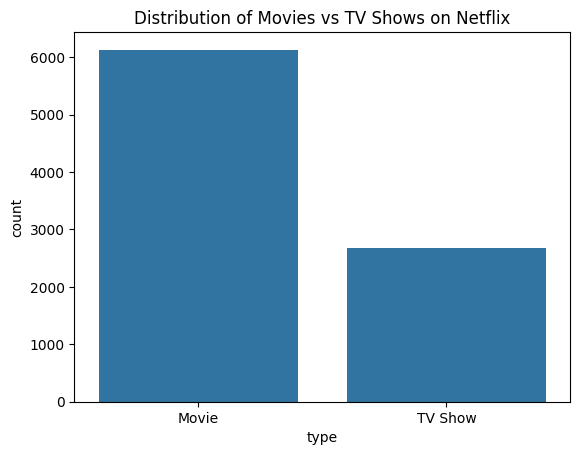

In [ ]:
df['type'].value_counts()
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.show()

**Insight:** The visualization shows that movies dominate Netflix's content library, significantly outnumbering TV shows.  
This suggests that Netflix has historically focused more on movie content, although TV shows still represent a substantial portion of the platform's catalog.

**Content Added to Netflix Over the Years:** This analysis explores how Netflix's content library has grown over time.  

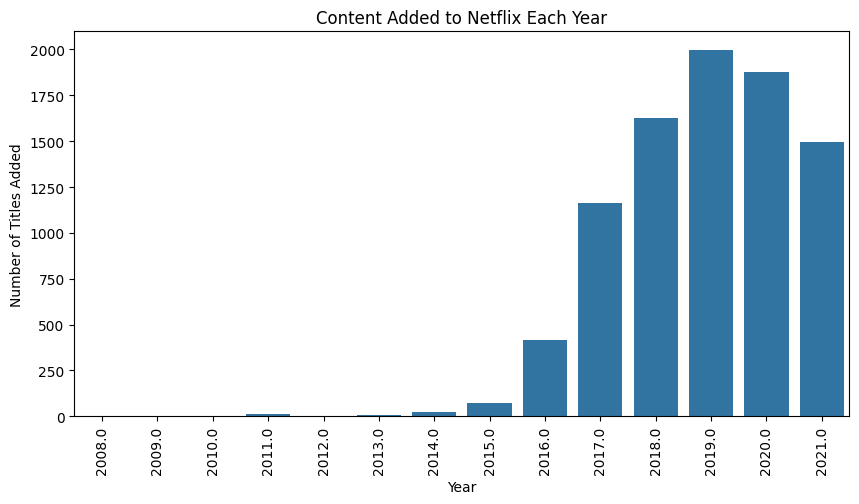

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year           #extract year from date_added

year_counts = df['year_added'].value_counts().sort_index()       #number of titles added each year

plt.figure(figsize=(10,5))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.xticks(rotation=90)
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.title("Content Added to Netflix Each Year")

plt.show()

**Insight:** The visualization shows a sharp increase in the number of titles added to Netflix after 2015.  
Content additions peaked around 2019–2020, reflecting Netflix's aggressive expansion of its streaming library and investment in global content during this period.

**Top Countries Producing Netflix Content:** This analysis identifies the countries that contribute the most titles to Netflix's content library. 

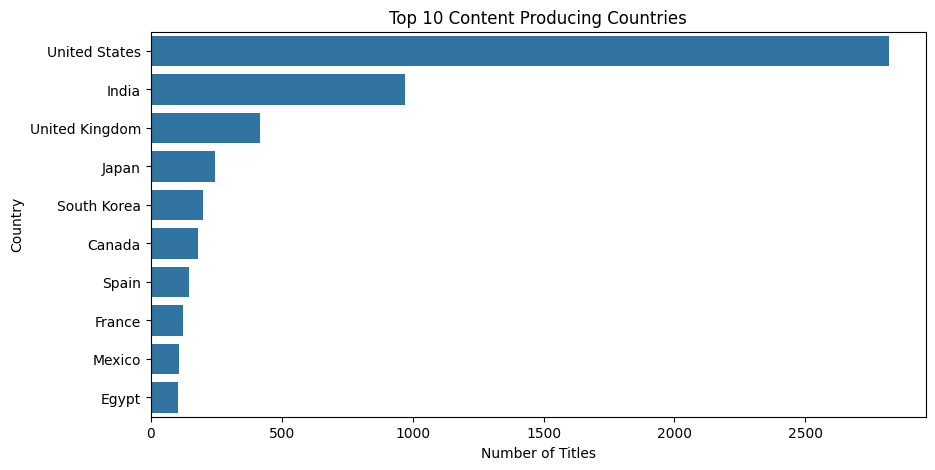

In [ ]:
countries = df[df['country'] != 'Unknown']
top_countries = countries['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

**Insight:** The visualization shows that the United States produces the largest number of titles available on Netflix, significantly surpassing other countries.  
India and the United Kingdom also contribute a substantial amount of content, highlighting Netflix's strong presence in both Western and Asian markets.  


**Distribution of Content Ratings:** This analysis explores the distribution of maturity ratings assigned to Netflix titles. 

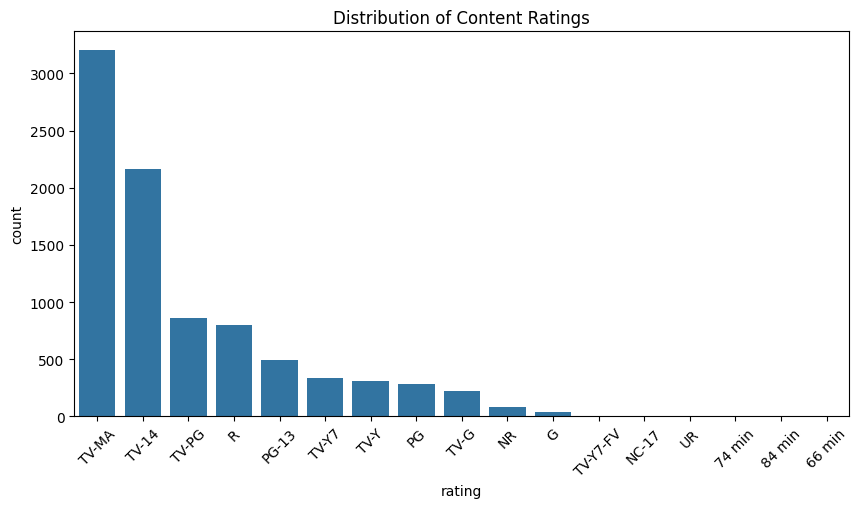

In [10]:
# most common ratings
plt.figure(figsize=(10,5))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution of Content Ratings")
plt.show()

**Insight:** The visualization shows that **TV-MA** is the most common rating among Netflix titles, followed by **TV-14**.  
This indicates that a large portion of Netflix content is targeted toward mature or young adult audiences, rather than children.  


**Top Genres on Netflix:** This analysis examines the most common genres available on Netflix. 

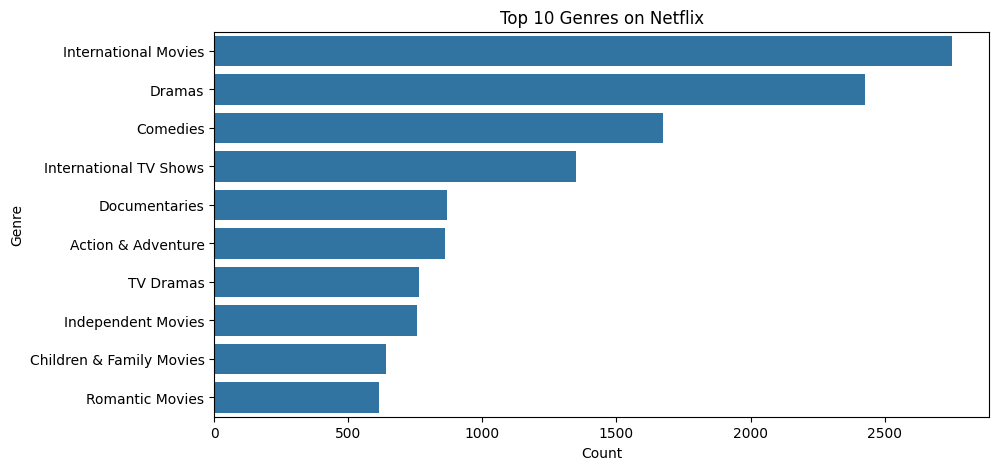

In [ ]:
genre_counts = df['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

**Insight:** The visualization shows that **International Movies** and **Dramas** are the most common genres available on Netflix.

**Top Directors on Netflix:** This analysis identifies the directors who have contributed the most titles to Netflix. 

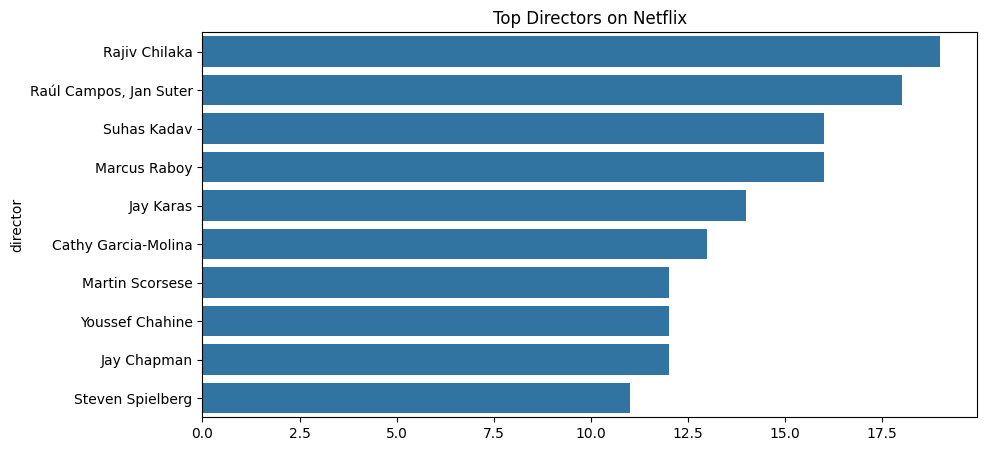

In [ ]:
directors = df[df['director'] != 'Unknown']     # remove unknown directors

top_directors = directors['director'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title("Top Directors on Netflix")
plt.show()

**Insight:** Directors such as **Rajiv Chilaka** and **Raúl Campos & Jan Suter** have the highest number of titles on the platform.  

**Correlation Analysis of Numeric Features:** This analysis examines the relationship between the numeric variables in the dataset. 

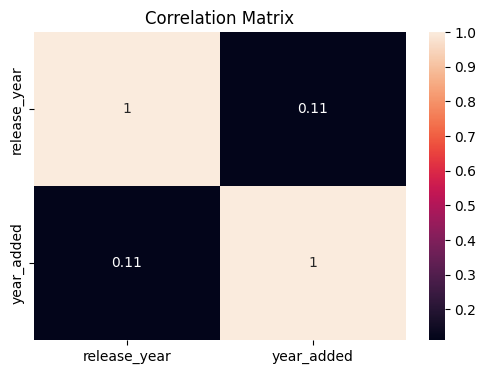

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

**Insight:** The correlation between **release_year** and **year_added** is relatively weak, indicating that the year a title was released does not strongly determine when it was added to Netflix.  


**Top Actors on Netflix:** This analysis identifies the actors who appear most frequently in Netflix titles. 

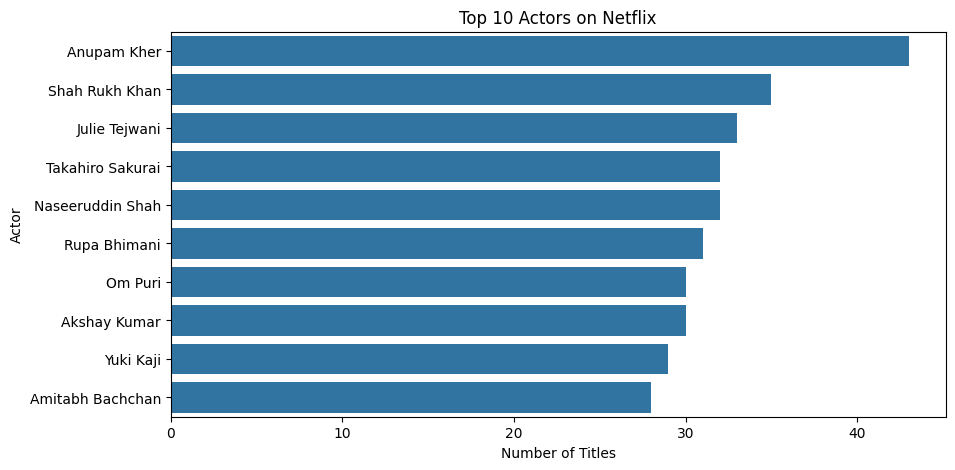

In [ ]:
actors = df[df['cast'] != 'Unknown']
actor_counts = actors['cast'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=actor_counts.values, y=actor_counts.index)
plt.title("Top 10 Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")
plt.show()

**Insight:** Actors such as **Anupam Kher** and **Shah Rukh Khan** have the highest number of appearances, indicating a strong presence of Indian cinema within Netflix's catalog.  

**Movies vs TV Shows Added Over Time:** This analysis compares how many movies and TV shows were added to Netflix each year. 

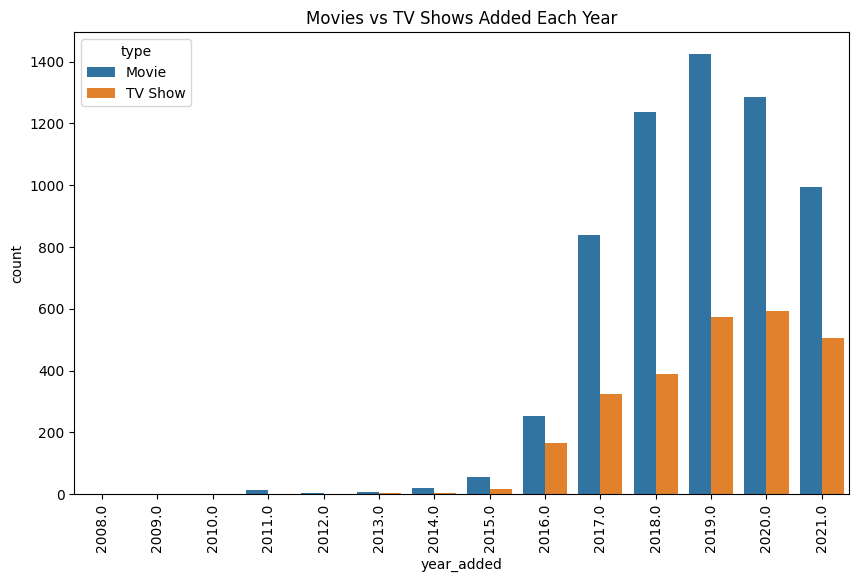

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='year_added', hue='type')
plt.xticks(rotation=90)
plt.title("Movies vs TV Shows Added Each Year")
plt.show()

**Insight:** The visualization shows that both movies and TV shows experienced significant growth on Netflix after 2015.  
However, movies consistently outnumber TV shows in most years, indicating that Netflix's library has historically been more movie-focused. 

**Movie Duration Distribution:** This analysis examines the distribution of movie durations available on Netflix. 

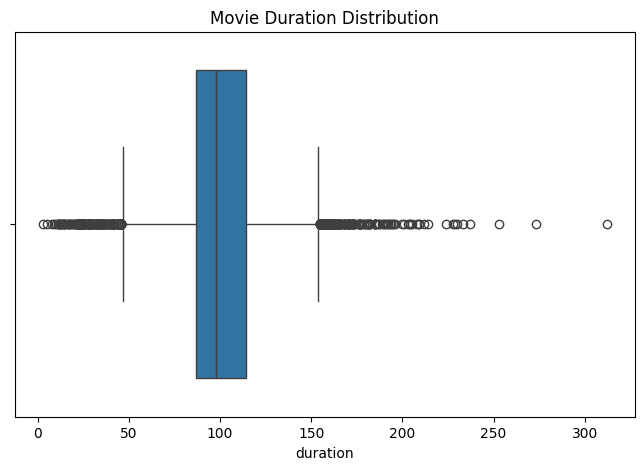

In [ ]:
movies = df[df['type']=='Movie'].copy()
movies = movies[movies['duration']!='Unknown']

movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = pd.to_numeric(movies['duration'])

plt.figure(figsize=(8,5))
sns.boxplot(x=movies['duration'])
plt.title("Movie Duration Distribution")
plt.show()

**Insight:**  The boxplot shows that most Netflix movies have a duration between 90 and 110 minutes, which is typical for standard feature-length films.  
However, there are several outliers representing very short films and unusually long movies. 

**Content Release Trend Over the Years:** This analysis explores how the release years of Netflix titles are distributed over time. 

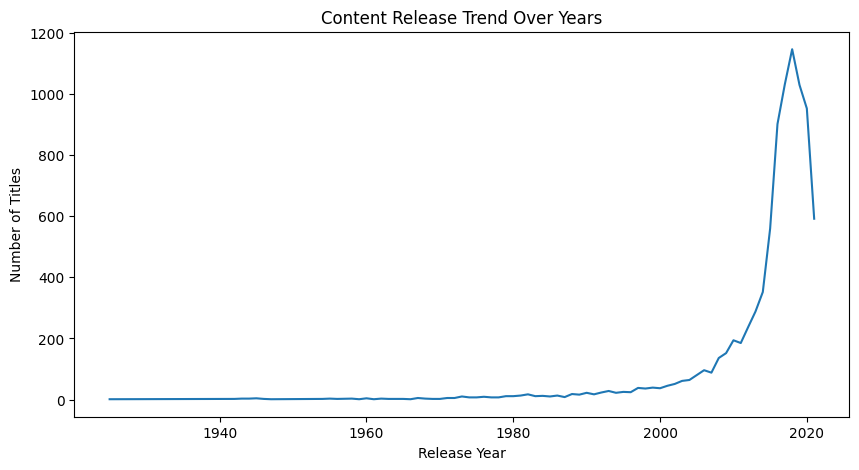

In [ ]:
# top release years
release_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=release_counts.index, y=release_counts.values)
plt.title("Content Release Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

**Insight:** The visualization shows that the number of titles released each year increases significantly in recent decades, especially after 2000.  


**Content Age on Netflix (Feature Engineering):** Here, a new feature called **content_age** is created to measure the time gap between when a title was originally released and when it was added to Netflix. 

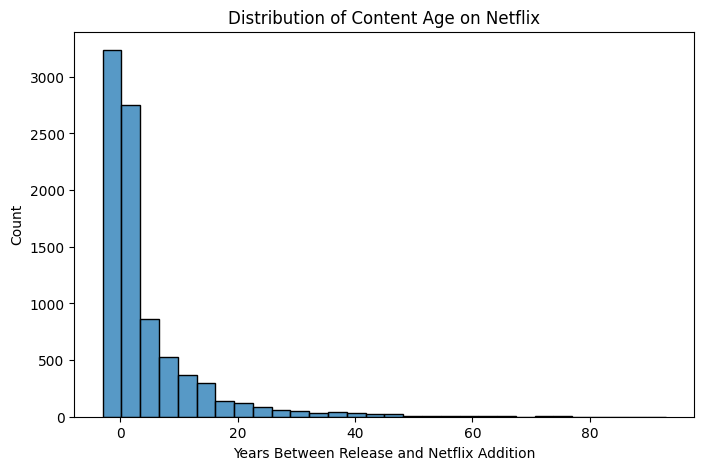

In [ ]:
df['content_age'] = df['year_added'] - df['release_year']

plt.figure(figsize=(8,5))
sns.histplot(df['content_age'], bins=30)
plt.title("Distribution of Content Age on Netflix")
plt.xlabel("Years Between Release and Netflix Addition")
plt.show()

**Insight:**  The distribution shows that most Netflix titles are added within 0–5 years of their original release. However, the long tail of the histogram indicates that Netflix also includes much older titles in its library.  

**Genre Trends on Netflix Over Time:** This analysis explores how the popularity of different genres on Netflix has evolved over the years.  

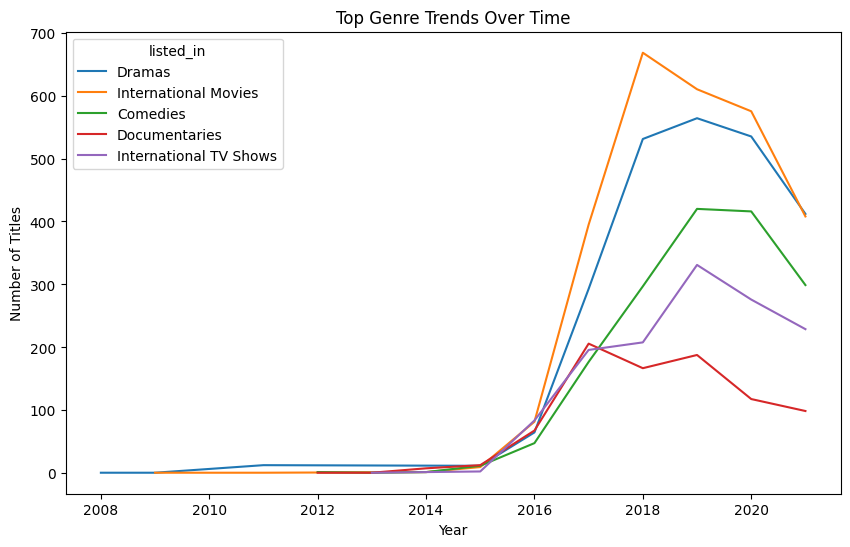

In [ ]:
genre_year = df[['year_added','listed_in']].copy()

genre_year['listed_in'] = genre_year['listed_in'].str.split(', ')       # split genres
genre_year = genre_year.explode('listed_in')

genre_trend = genre_year.groupby(['year_added','listed_in']).size().reset_index(name='count')    # count genres per year

top_genres = genre_year['listed_in'].value_counts().head(5).index
genre_trend = genre_trend[genre_trend['listed_in'].isin(top_genres)]

plt.figure(figsize=(10,6))

sns.lineplot(data=genre_trend,
             x='year_added',
             y='count',
             hue='listed_in')

plt.title("Top Genre Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

**Insight:** The visualization shows that several genres experienced rapid growth after 2016, particularly **International Movies** and **Dramas**.  


**Content Type Distribution by Country:** This analysis examines how different countries contribute to Netflix's catalog in terms of content type.  

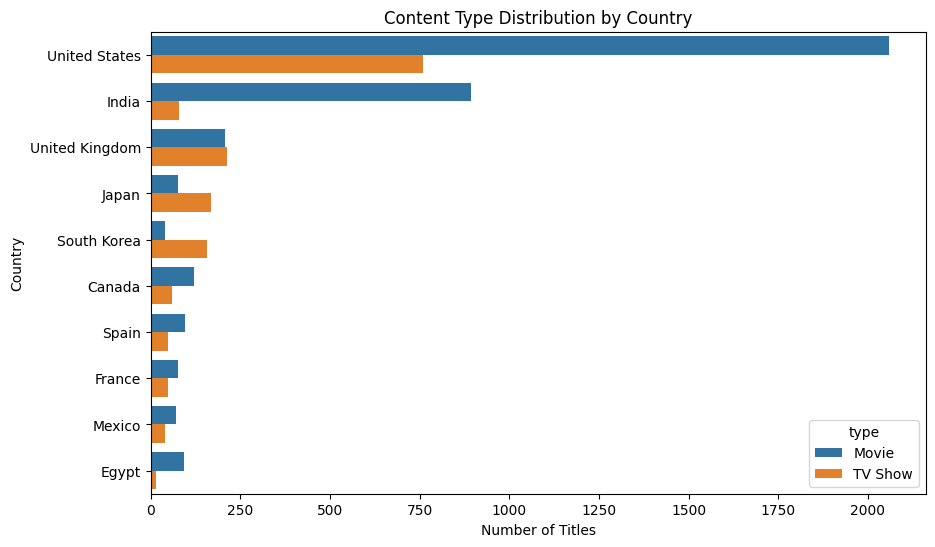

In [ ]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10).index
country_type = df[df['country'].isin(top_countries)]

plt.figure(figsize=(10,6))
sns.countplot(data=country_type,
              y='country',
              hue='type',
              order=top_countries)
plt.title("Content Type Distribution by Country")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

**Insight:** The visualization shows that the United States dominates Netflix's content production, especially in movies. India also contributes a large number of titles, primarily movies, while countries such as Japan and South Korea show a stronger presence in TV shows. 

## Key Findings

• Movies dominate Netflix's content library, significantly outnumbering TV shows on the platform.

• Netflix experienced rapid growth in its catalog after **2015**, with the number of titles added peaking around **2019–2020**.

• The **United States** contributes the largest number of titles on Netflix, followed by countries like **India and the United Kingdom**, highlighting Netflix's global content strategy.

• The most common content ratings are **TV-MA and TV-14**, indicating that a large portion of Netflix content is targeted toward mature and young adult audiences.

• **International Movies and Dramas** are the most popular genres, reflecting Netflix's emphasis on globally diverse entertainment.

• Several actors such as **Anupam Kher and Shah Rukh Khan** appear frequently in Netflix titles, showing strong representation of international cinema.

• Most Netflix movies have a duration between **90 and 110 minutes**, which aligns with typical feature-length films.

• The majority of titles are added to Netflix within **0–5 years of their release**, although the platform also includes older licensed content to maintain a diverse library.

• Genre trends show significant growth in **International Movies and Dramas after 2016**, indicating Netflix's expansion into global markets.

• Different countries contribute different types of content, with the **United States producing mostly movies**, while some countries show a stronger presence in TV shows.

## Conclusion

This exploratory data analysis provides insights into Netflix's content distribution and growth trends. The platform is dominated by movies, although TV shows have increased significantly in recent years. The analysis also highlights Netflix's global expansion strategy, with strong contributions from countries like the United States and India, and the increasing popularity of international genres.
Overall, Netflix maintains a diverse catalog combining recent releases with older licensed content across multiple regions and genres.